In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.cluster import KMeans

In [2]:
df = pd.read_csv("survey_cleaned.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (411, 23)


,age_group,occupation,gender,smartphone_type,screen_time,daily_app_categories,most_used_category,ad_frequency,frequent_ad_format,most_excessive_ad_category,...,ads_close_app,ads_uninstall_app,tolerated_ad_format,most_annoying_ad_time,pay_for_adfree,ads_interrupt_usage_score,ads_cause_frustration_score,ads_reduce_enjoyment_score,ads_close_app_score,ad_fatigue_index
0,18–24,Student,Male,Android,4–6 hours,"Social Media, Video / OTT, Gaming, Shopping / ...","Social Media, Video / OTT, Gaming",Often,Unskippable ads,Gaming,...,Neutral,Yes,Skippable video ads,Evening,No,4.0,5.0,5.0,3.0,4.25
1,18–24,Student,Male,iOS,4–6 hours,"Social Media, Video / OTT, Education","Social Media, Video / OTT, Education",Often,Video ads,Video / OTT,...,Agree,Yes,Skippable video ads,Evening,Yes,5.0,5.0,4.0,4.0,4.50
2,18–24,Student,Male,iOS,More than 6 hours,"Social Media, Video / OTT, Gaming","Social Media, Video / OTT, Gaming",Sometimes,Sponsored posts,Social Media,...,Disagree,No,Skippable video ads,Evening,Yes,4.0,5.0,5.0,2.0,4.00
3,18–24,Student,Male,Android,4–6 hours,"Social Media, Video / OTT, Shopping / E-commer...","Social Media, Shopping / E-commerce, Education",Sometimes,Video ads,Social Media,...,Neutral,Yes,Rewarded ads,NaN,Yes,3.0,4.0,4.0,3.0,3.50
4,Below 18,Student,Female,iOS,2–4 hours,"Social Media, Video / OTT, Shopping / E-commerce","Social Media, Video / OTT, Shopping / E-commerce",Sometimes,Banner ads,Video / OTT,...,Disagree,No,Banner ads,Morning,No,3.0,3.0,4.0,2.0,3.00


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 411 entries, 0 to 410
Data columns (total 23 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   age_group                    410 non-null    object 
 1   occupation                   410 non-null    object 
 2   gender                       410 non-null    object 
 3   smartphone_type              408 non-null    object 
 4   screen_time                  410 non-null    object 
 5   daily_app_categories         391 non-null    object 
 6   most_used_category           385 non-null    object 
 7   ad_frequency                 410 non-null    object 
 8   frequent_ad_format           409 non-null    object 
 9   most_excessive_ad_category   410 non-null    object 
 10  ads_interrupt_usage          410 non-null    object 
 11  ads_cause_frustration        410 non-null    object 
 12  ads_reduce_enjoyment         410 non-null    object 
 13  ads_close_app       

In [4]:
df.describe()

,ads_interrupt_usage_score,ads_cause_frustration_score,ads_reduce_enjoyment_score,ads_close_app_score,ad_fatigue_index
count,410.000000,410.000000,410.000000,410.000000,410.000000
mean,3.221951,3.241463,3.324390,3.243902,3.257927
std,1.388745,1.411700,1.396692,1.389455,0.925279
min,1.000000,1.000000,1.000000,1.000000,1.000000
25%,2.000000,2.000000,2.000000,2.000000,2.500000
50%,3.000000,3.000000,4.000000,3.000000,3.250000
75%,4.000000,4.000000,5.000000,4.000000,4.000000
max,5.000000,5.000000,5.000000,5.000000,5.000000


In [5]:
df.isnull().sum()

,0
age_group,1
occupation,1
gender,1
smartphone_type,3
screen_time,1
daily_app_categories,20
most_used_category,26
ad_frequency,1
frequent_ad_format,2
most_excessive_ad_category,1


In [6]:
df_encoded = df.copy()

le = LabelEncoder()

for col in df_encoded.select_dtypes(include="object").columns:
    df_encoded[col] = le.fit_transform(df_encoded[col])

df_encoded.head()

,age_group,occupation,gender,smartphone_type,screen_time,daily_app_categories,most_used_category,ad_frequency,frequent_ad_format,most_excessive_ad_category,...,ads_close_app,ads_uninstall_app,tolerated_ad_format,most_annoying_ad_time,pay_for_adfree,ads_interrupt_usage_score,ads_cause_frustration_score,ads_reduce_enjoyment_score,ads_close_app_score,ad_fatigue_index
0,0,2,1,0,1,64,52,0,3,1,...,2,1,2,1,0,4.0,5.0,5.0,3.0,4.25
1,0,2,1,1,1,55,51,0,4,6,...,0,1,2,1,1,5.0,5.0,4.0,4.0,4.50
2,0,2,1,1,3,56,52,2,2,4,...,1,0,2,1,1,4.0,5.0,5.0,2.0,4.00
3,0,2,1,0,1,80,42,2,4,4,...,2,1,1,4,1,3.0,4.0,4.0,3.0,3.50
4,4,2,0,1,0,74,67,2,0,6,...,1,0,0,3,0,3.0,3.0,4.0,2.0,3.00


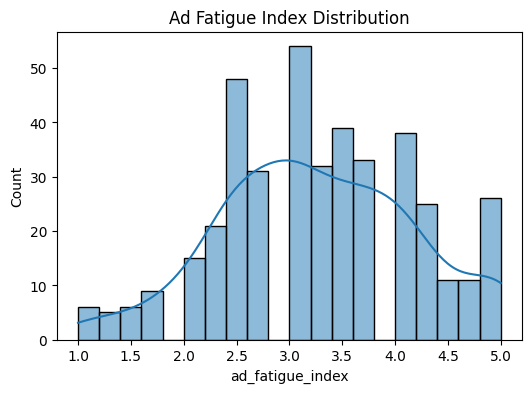

In [7]:
plt.figure(figsize=(6,4))
sns.histplot(df["ad_fatigue_index"], bins=20, kde=True)
plt.title("Ad Fatigue Index Distribution")
plt.show()

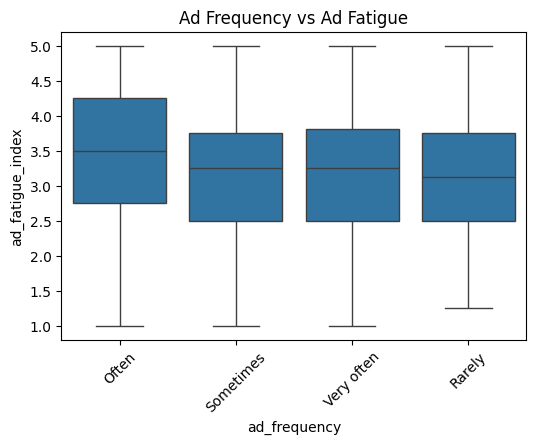

In [8]:
plt.figure(figsize=(6,4))
sns.boxplot(x="ad_frequency", y="ad_fatigue_index", data=df)
plt.title("Ad Frequency vs Ad Fatigue")
plt.xticks(rotation=45)
plt.show()

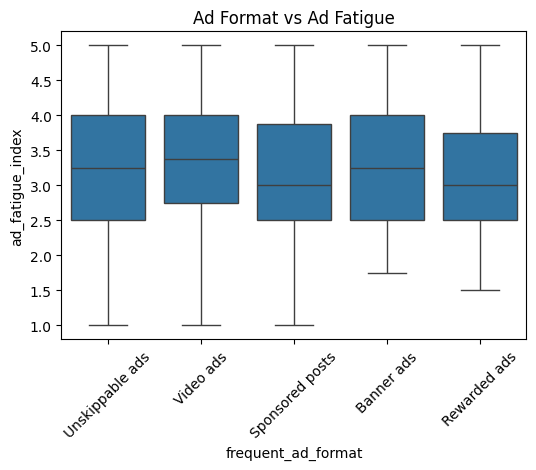

In [9]:
plt.figure(figsize=(6,4))
sns.boxplot(x="frequent_ad_format", y="ad_fatigue_index", data=df)
plt.title("Ad Format vs Ad Fatigue")
plt.xticks(rotation=45)
plt.show()

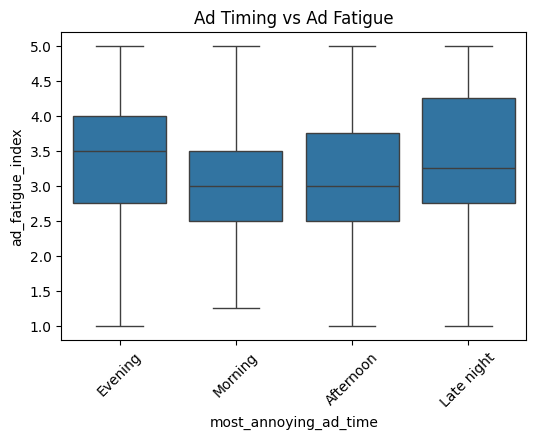

In [10]:
plt.figure(figsize=(6,4))
sns.boxplot(x="most_annoying_ad_time", y="ad_fatigue_index", data=df)
plt.title("Ad Timing vs Ad Fatigue")
plt.xticks(rotation=45)
plt.show()

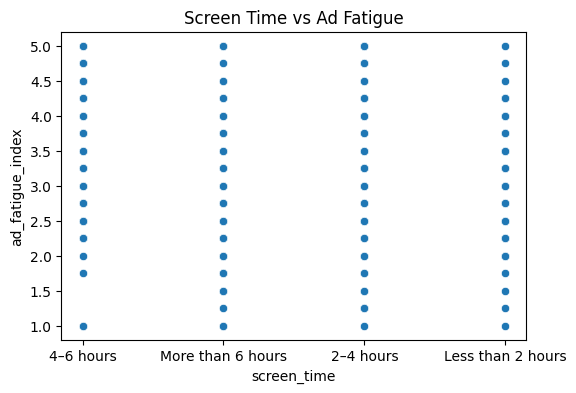

In [11]:
plt.figure(figsize=(6,4))
sns.scatterplot(
    x=df["screen_time"],
    y=df["ad_fatigue_index"]
)

plt.title("Screen Time vs Ad Fatigue")
plt.show()

In [17]:
df_encoded = df.copy()

le = LabelEncoder()

for col in df_encoded.select_dtypes(include="object").columns:

    df_encoded[col] = le.fit_transform(df_encoded[col])

In [18]:
df_encoded.head()

,age_group,occupation,gender,smartphone_type,screen_time,daily_app_categories,most_used_category,ad_frequency,frequent_ad_format,most_excessive_ad_category,...,ads_close_app,ads_uninstall_app,tolerated_ad_format,most_annoying_ad_time,pay_for_adfree,ads_interrupt_usage_score,ads_cause_frustration_score,ads_reduce_enjoyment_score,ads_close_app_score,ad_fatigue_index
0,0,2,1,0,1,64,52,0,3,1,...,2,1,2,1,0,4.0,5.0,5.0,3.0,4.25
1,0,2,1,1,1,55,51,0,4,6,...,0,1,2,1,1,5.0,5.0,4.0,4.0,4.50
2,0,2,1,1,3,56,52,2,2,4,...,1,0,2,1,1,4.0,5.0,5.0,2.0,4.00
3,0,2,1,0,1,80,42,2,4,4,...,2,1,1,4,1,3.0,4.0,4.0,3.0,3.50
4,4,2,0,1,0,74,67,2,0,6,...,1,0,0,3,0,3.0,3.0,4.0,2.0,3.00


In [19]:
df_encoded.isnull().sum()

,0
age_group,0
occupation,0
gender,0
smartphone_type,0
screen_time,0
daily_app_categories,0
most_used_category,0
ad_frequency,0
frequent_ad_format,0
most_excessive_ad_category,0


In [22]:
for col in df_encoded.select_dtypes(include=np.number).columns:

    df_encoded[col].fillna(df_encoded[col].median(), inplace=True)

/tmp/ipykernel_160/3371601009.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_encoded[col].fillna(df_encoded[col].median(), inplace=True)


In [23]:
df_encoded.isnull().sum()

,0
age_group,0
occupation,0
gender,0
smartphone_type,0
screen_time,0
daily_app_categories,0
most_used_category,0
ad_frequency,0
frequent_ad_format,0
most_excessive_ad_category,0


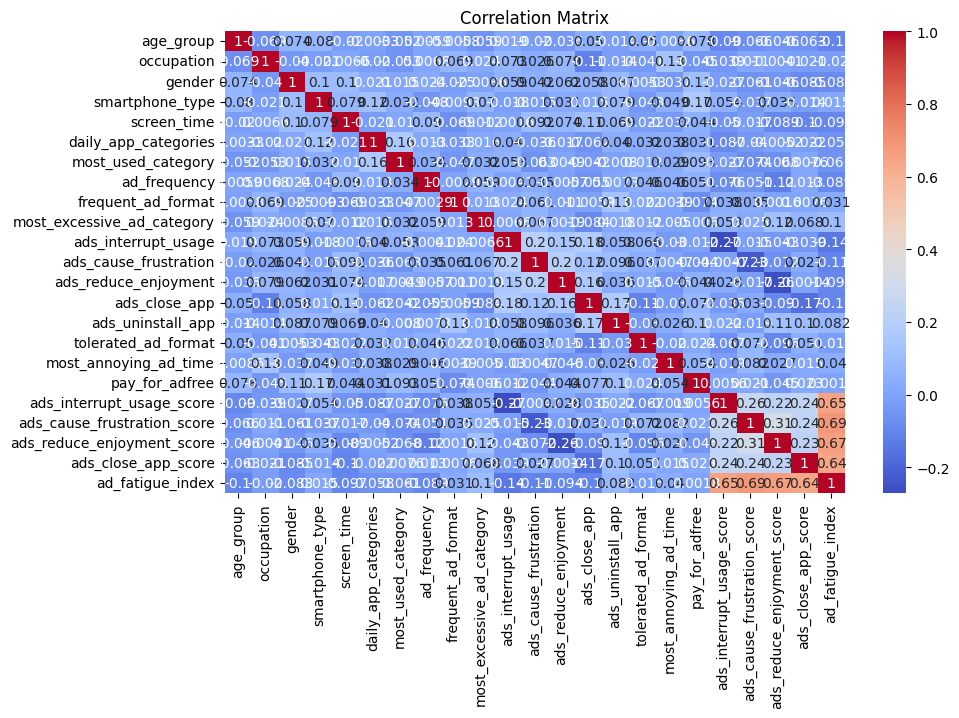

In [24]:
plt.figure(figsize=(10,6))

sns.heatmap(df_encoded.corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Matrix")

plt.show()

In [25]:
y = df_encoded["ad_fatigue_index"]

In [26]:
X = df_encoded.drop("ad_fatigue_index", axis=1)

In [27]:
X_train, X_test, y_train, y_test = train_test_split(

    X, y,
    test_size=0.2,
    random_state=42

)

In [28]:
lr = LinearRegression()

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

In [29]:
print("Linear Regression")

print("MAE:", mean_absolute_error(y_test, pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred_lr)))
print("R2:", r2_score(y_test, pred_lr))

Linear Regression
MAE: 1.5508344274101283e-14
RMSE: 2.1543869495205707e-14
R2: 1.0


In [30]:
dt = DecisionTreeRegressor(random_state=42)

dt.fit(X_train, y_train)

pred_dt = dt.predict(X_test)

In [31]:
print("Decision Tree")

print("MAE:", mean_absolute_error(y_test, pred_dt))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred_dt)))
print("R2:", r2_score(y_test, pred_dt))

Decision Tree
MAE: 0.20180722891566266
RMSE: 0.29170252217933107
R2: 0.9203603695401128


In [32]:
rf = RandomForestRegressor(

    n_estimators=200,
    random_state=42

)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

In [33]:
print("Random Forest")

print("MAE:", mean_absolute_error(y_test, pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred_rf)))
print("R2:", r2_score(y_test, pred_rf))

Random Forest
MAE: 0.15039156626506026
RMSE: 0.1893844062040299
R2: 0.9664310852693431


In [34]:
results = pd.DataFrame({

"Model":[
"Linear Regression",
"Decision Tree",
"Random Forest"
],

"MAE":[
mean_absolute_error(y_test,pred_lr),
mean_absolute_error(y_test,pred_dt),
mean_absolute_error(y_test,pred_rf)
],

"RMSE":[
np.sqrt(mean_squared_error(y_test,pred_lr)),
np.sqrt(mean_squared_error(y_test,pred_dt)),
np.sqrt(mean_squared_error(y_test,pred_rf))
],

"R2":[
r2_score(y_test,pred_lr),
r2_score(y_test,pred_dt),
r2_score(y_test,pred_rf)
]

})

results

,Model,MAE,RMSE,R2
0,Linear Regression,1.550834e-14,2.154387e-14,1.000000
1,Decision Tree,2.018072e-01,2.917025e-01,0.920360
2,Random Forest,1.503916e-01,1.893844e-01,0.966431


In [35]:
importance = pd.Series(

rf.feature_importances_,
index=X.columns

)

importance.sort_values(ascending=False)

,0
ads_cause_frustration_score,0.327402
ads_reduce_enjoyment_score,0.231013
ads_close_app_score,0.188384
ads_interrupt_usage_score,0.147163
ads_close_app,0.017763
ads_cause_frustration,0.016786
ads_interrupt_usage,0.009650
daily_app_categories,0.007560
ads_reduce_enjoyment,0.007482
most_used_category,0.007062


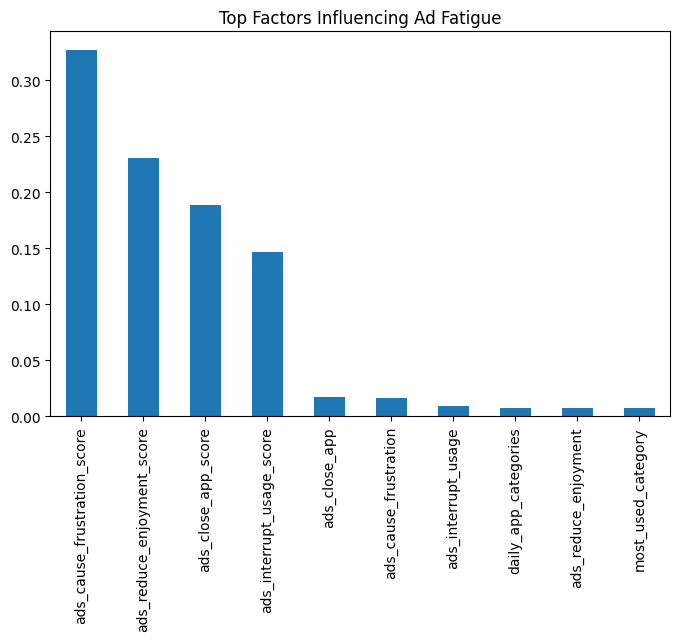

In [36]:
plt.figure(figsize=(8,5))

importance.sort_values(ascending=False).head(10).plot(kind="bar")

plt.title("Top Factors Influencing Ad Fatigue")

plt.show()

In [40]:
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
)

importance.sort_values(ascending=False)

,0
ads_cause_frustration_score,0.327402
ads_reduce_enjoyment_score,0.231013
ads_close_app_score,0.188384
ads_interrupt_usage_score,0.147163
ads_close_app,0.017763
ads_cause_frustration,0.016786
ads_interrupt_usage,0.009650
daily_app_categories,0.007560
ads_reduce_enjoyment,0.007482
most_used_category,0.007062


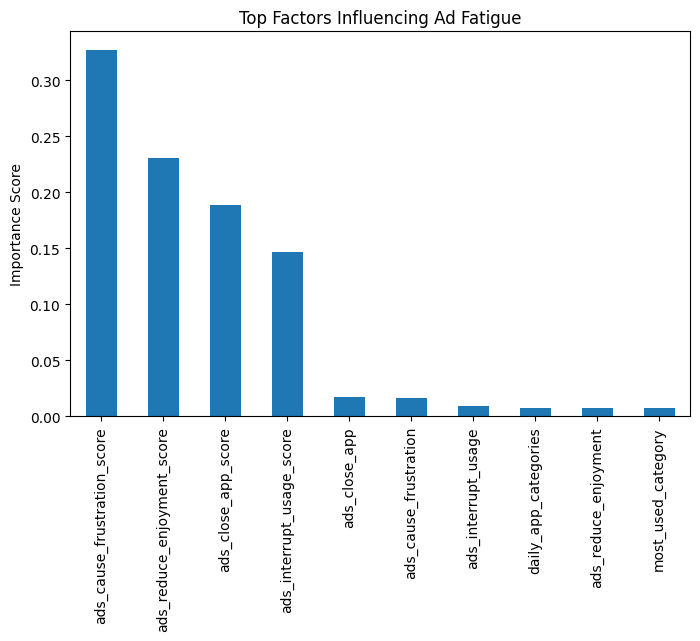

In [41]:
plt.figure(figsize=(8,5))

importance.sort_values(ascending=False).head(10).plot(kind="bar")

plt.title("Top Factors Influencing Ad Fatigue")

plt.ylabel("Importance Score")

plt.show()

In [42]:
cluster_features = df[[
    "ads_interrupt_usage_score",
    "ads_cause_frustration_score",
    "ads_reduce_enjoyment_score",
    "ads_close_app_score"
]]

In [43]:
cluster_features.isnull().sum()

,0
ads_interrupt_usage_score,1
ads_cause_frustration_score,1
ads_reduce_enjoyment_score,1
ads_close_app_score,1


In [44]:
cluster_features = cluster_features.fillna(cluster_features.median())

In [45]:
cluster_features.isnull().sum()

,0
ads_interrupt_usage_score,0
ads_cause_frustration_score,0
ads_reduce_enjoyment_score,0
ads_close_app_score,0


In [46]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_data = scaler.fit_transform(cluster_features)

In [47]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

clusters = kmeans.fit_predict(scaled_data)

df["user_segment"] = clusters

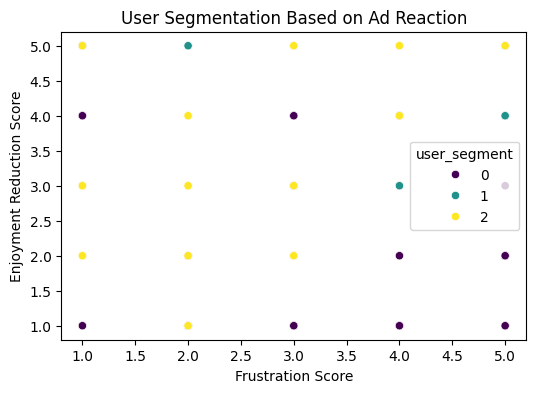

In [48]:
plt.figure(figsize=(6,4))

sns.scatterplot(
    x=df["ads_cause_frustration_score"],
    y=df["ads_reduce_enjoyment_score"],
    hue=df["user_segment"],
    palette="viridis"
)

plt.title("User Segmentation Based on Ad Reaction")

plt.xlabel("Frustration Score")
plt.ylabel("Enjoyment Reduction Score")

plt.show()